<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/KDD_Kamarul_day3_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 — Regression (continued) & Classification — Project KDD (NSL-KDD)

**Continues** Day 2 (`KDD_Kamarul_day2_regression.ipynb`). On Day 2 we built our first supervised model:
an **Ordinary Least Squares linear regression** that predicted the 0/1 target `is_attack` (the *Linear
Probability Model*), and we practised OLS, p-values, RMSE, the log-transform, the train/test split and
cross-validation.

Today follows the **third lecture** (`03.regression_contd-and-classification`), which has two halves:

**Part A — finishing the regression toolbox** (still on Day 2's linear model):
Polynomial Regression → Bias–Variance trade-off → Regularization → Scaling → Feature Selection.

**Part B — Classification** (the proper tool for *attack vs normal*):
Logistic Regression → the decision boundary → performance metrics (confusion matrix, precision/recall/F1)
→ Multinomial Logistic Regression (the 5 attack *categories*) → **class imbalance** → hyper-parameter tuning.

Like Day 2, this notebook is **self-contained**: it re-loads the raw `KDDTrain__20Percent.txt`, redoes the
small amount of prep we need, and uses only `scikit-learn` (one technique, SMOTE, is implemented inline so
no extra install is required).


## 0. Load libraries

In [ ]:
import pandas as pd               # dataframes (tables)
import numpy as np                # numerical operations
import math                       # for sqrt
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import RFE
from sklearn.metrics import (mean_squared_error, accuracy_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8, 4)
np.set_printoptions(precision=3, suppress=True)

## 1. Load the data and redo the essential prep

We start from the **raw** file so the notebook runs on its own. We rebuild three things:

1. the binary target `is_attack` (1 = attack, 0 = normal) — same as Day 2;
2. the **log** versions of the heavily-skewed magnitude features (same as Day 2);
3. **new today:** a 5-class `category` target (`normal`, `DoS`, `Probe`, `R2L`, `U2R`). NSL-KDD groups its
   23 specific attack names into these four attack families. We will need this multi-class target for the
   *Multinomial Logistic Regression* and *class imbalance* parts.

On Colab, drag `KDDTrain__20Percent.txt` into the file panel first.

In [ ]:
FILENAME = 'KDDTrain__20Percent.txt'
COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']

import os
if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        up = files.upload(); FILENAME = list(up.keys())[0]
    except Exception:
        raise FileNotFoundError(f'{FILENAME} not found and not on Colab.')

df = pd.read_csv(FILENAME)
df.columns = COL_NAMES

# (1) binary target
df['is_attack'] = (df['attack'] != 'normal').astype(int)

# (2) log(1+x) of the skewed magnitude features (same set as Day 2)
to_log = ['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count']
for c in to_log:
    df[c + '_log'] = np.log1p(df[c])

# (3) 5-class category target: map the 23 attack names into NSL-KDD's four families
DOS   = ['back','land','neptune','pod','smurf','teardrop','apache2','udpstorm','processtable','worm','mailbomb']
PROBE = ['satan','ipsweep','nmap','portsweep','mscan','saint']
R2L   = ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster','warezclient','spy',
         'xlock','xsnoop','snmpguess','snmpgetattack','httptunnel','sendmail','named']
U2R   = ['buffer_overflow','loadmodule','rootkit','perl','sqlattack','xterm','ps']
def to_category(a):
    if a == 'normal': return 'normal'
    if a in DOS:      return 'DoS'
    if a in PROBE:    return 'Probe'
    if a in R2L:      return 'R2L'
    if a in U2R:      return 'U2R'
    return 'normal'                      # any unseen name -> treat as normal (none in this subset)
df['category'] = df['attack'].apply(to_category)

print('shape:', df.shape, '| attack rate:', round(df['is_attack'].mean(), 3))
print('\ncategory counts (note the huge imbalance):')
print(df['category'].value_counts())

Saving KDDTrain+_20Percent.txt to KDDTrain+_20Percent.txt
shape: (25192, 52) | attack rate: 0.466

category counts (note the huge imbalance):
category
normal    13449
DoS        9234
Probe      2289
R2L         209
U2R          11
Name: count, dtype: int64


Look at those `category` counts: `normal` and `DoS` have **thousands** of samples, `Probe` a couple
thousand, `R2L` only ~200, and `U2R` a mere **11**. That extreme imbalance is the heart of the lecture's
final section — and unlike a toy example, here it is *real* and it matters (U2R = privilege-escalation
attacks, the most dangerous kind).

### The feature set we will reuse

From Day 2's correlation ranking we keep the ten strongest predictors of `is_attack` (a mix of the
shared-service rates, the log-magnitude features, and the error rates). We define them once here.

In [ ]:
FEATURES = ['same_srv_rate', 'src_bytes_log', 'dst_bytes_log', 'dst_host_srv_count', 'logged_in',
            'serror_rate', 'diff_srv_rate', 'count_log', 'dst_host_same_srv_rate', 'srv_count_log']
print(len(FEATURES), 'features:', FEATURES)

10 features: ['same_srv_rate', 'src_bytes_log', 'dst_bytes_log', 'dst_host_srv_count', 'logged_in', 'serror_rate', 'diff_srv_rate', 'count_log', 'dst_host_same_srv_rate', 'srv_count_log']


# Part A — Finishing the regression toolbox

The lecture's first half stays in **regression** (Day 2's linear model that predicts the *number*
`is_attack`). It adds four tools that apply to *any* model: polynomial features, the bias–variance
trade-off, regularization, scaling, and feature selection. We demonstrate each on our data, then carry the
lessons into classification in Part B.

## A1. Polynomial regression — and choosing the degree *p*

A linear model fits a straight line, `h(x) = θ₀ + θ₁·x`. A **polynomial regression of degree *p*** adds
powers of the feature:

$$h_\theta(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \dots + \theta_p x^p$$

The clever bit (slide 3): this is **still linear regression** — we just feed it the extra columns
`x, x², …, xᵖ`. `scikit-learn`'s `PolynomialFeatures(p)` builds those columns for us.

*p* is a **hyper-parameter** — a knob *we* choose, not something the fit learns. How do we choose it? By
watching the **test** error, not the training error. Let's sweep the degree on a single feature
(`src_bytes_log`) and record both.

In [ ]:
dtr, dte = train_test_split(df, test_size=0.3, random_state=19)
ytr = dtr['is_attack'].values
yte = dte['is_attack'].values

degrees = range(1, 8)
train_rmse, test_rmse = [], []
for p in degrees:
    model = make_pipeline(PolynomialFeatures(p), LinearRegression())
    model.fit(dtr[['src_bytes_log']], ytr)
    train_rmse.append(math.sqrt(mean_squared_error(ytr, model.predict(dtr[['src_bytes_log']]))))
    test_rmse.append( math.sqrt(mean_squared_error(yte, model.predict(dte[['src_bytes_log']]))))

for p, tr, te in zip(degrees, train_rmse, test_rmse):
    print(f'degree {p}: train RMSE {tr:.4f}   test RMSE {te:.4f}')

degree 1: train RMSE 0.3431   test RMSE 0.3381
degree 2: train RMSE 0.2938   test RMSE 0.2892
degree 3: train RMSE 0.2899   test RMSE 0.2843
degree 4: train RMSE 0.2826   test RMSE 0.3059
degree 5: train RMSE 0.2733   test RMSE 0.3770
degree 6: train RMSE 0.2714   test RMSE 0.3386
degree 7: train RMSE 0.2703   test RMSE 0.6444


## A2. The Bias–Variance trade-off, drawn

Plot those two curves. This reproduces, **on our own data**, the famous picture from slides 7–8.

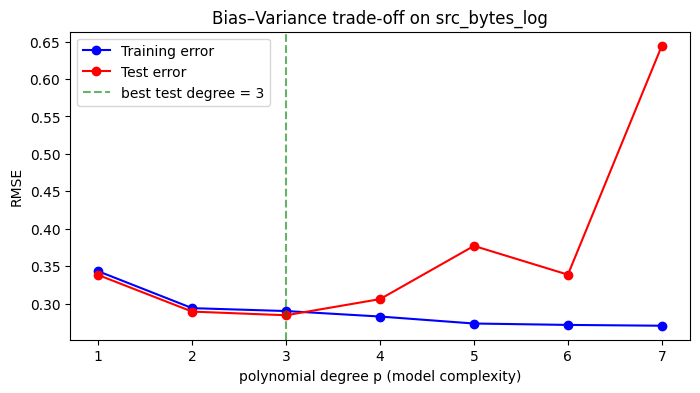

In [ ]:
fig, ax = plt.subplots()
ax.plot(list(degrees), train_rmse, 'o-', color='blue', label='Training error')
ax.plot(list(degrees), test_rmse,  'o-', color='red',  label='Test error')
best = int(np.argmin(test_rmse)) + 1
ax.axvline(best, color='green', ls='--', alpha=0.6, label=f'best test degree = {best}')
ax.set(xlabel='polynomial degree p (model complexity)', ylabel='RMSE',
       title='Bias–Variance trade-off on src_bytes_log')
ax.legend(); plt.show()

**What the curve shows (this is the whole lecture in one picture):**

* **Training error falls forever.** A more flexible model can always hug the training points more tightly —
  so the blue curve only ever goes down. Training error is *not* a way to choose *p*.
* **Test error is U-shaped.** Too-low degree (left) → **underfitting / high bias**: the model is too rigid.
  Too-high degree (right) → **overfitting / high variance**: the model memorises noise. The sweet spot is
  the bottom of the U — here **degree 3**.
* At degree 7 the training error is the lowest of all, yet the **test** RMSE explodes (≈ 0.64 vs 0.28 at
  degree 3). That gap *is* overfitting: great on data it has seen, useless on data it hasn't.

This is the **bias–variance trade-off** (slide 8): pushing training error down (less bias) eventually pushes
test error up (more variance). You cannot minimise both at once — you find the balance.

## A3. Regularization — taming a model that's too complex

Instead of *lowering the degree*, we can keep the flexible model but **discourage large coefficients**. We
add a penalty to the cost (slide 10):

$$J(\theta) = \underbrace{\tfrac1M\sum_i\big(y^{(i)}-h_\theta(x^{(i)})\big)^2}_{\text{fit the data}}
+ \underbrace{\alpha\sum_{j\ge1}\theta_j^2}_{\text{keep }\theta\text{ small}}$$

This is **Ridge regression** (the `α∑θ²` penalty is called *L2*). Bigger `α` ⇒ smaller coefficients ⇒
simpler, smoother model. Two subtleties from the slides:

* The **bias term θ₀ is not penalised** (`j ≥ 1`): it is only an offset, it adds no complexity.
* We add the penalty to the **training** cost only. When we *report* test error we use the **plain MSE**
  (no penalty term) — the penalty is a training-time tool, not part of the score (slide 20).

Take the catastrophically over-fit **degree-7** model from above and watch Ridge rescue it as `α` grows.

In [ ]:
poly7 = ['src_bytes_log']
alphas = [0.0, 1, 10, 100, 1000, 5000, 20000]
print(f'{"alpha":>8}   {"train RMSE":>10}   {"test RMSE":>10}')
for a in alphas:
    reg = LinearRegression() if a == 0 else Ridge(alpha=a)
    model = make_pipeline(StandardScaler(), PolynomialFeatures(7), reg).fit(dtr[poly7], ytr)
    tr = math.sqrt(mean_squared_error(ytr, model.predict(dtr[poly7])))
    te = math.sqrt(mean_squared_error(yte, model.predict(dte[poly7])))
    tag = '  <- no regularization (overfit)' if a == 0 else ('  <- sweet spot' if a == 5000 else
          ('  <- over-regularized (underfit)' if a == 20000 else ''))
    print(f'{a:>8}   {tr:>10.4f}   {te:>10.4f}{tag}')

   alpha   train RMSE    test RMSE
     0.0       0.2703       0.6444  <- no regularization (overfit)
       1       0.2703       0.6370
      10       0.2705       0.5887
     100       0.2752       0.5943
    1000       0.2900       0.6551
    5000       0.3033       0.3284  <- sweet spot
   20000       0.3338       0.9423  <- over-regularized (underfit)


**Reading it (slide 11's two extremes, made concrete):**

* `α = 0` is plain regression — the over-fit degree-7 model, test RMSE ≈ **0.64**.
* As `α` grows, the coefficients shrink and the test error improves, bottoming out around `α ≈ 5000`
  (test RMSE ≈ **0.33**, almost back to the ideal degree-3 model's 0.28). Regularization *fixed* the
  overfit without us touching the degree.
* Push `α` too far (`α = 20000`) and we **over-regularize**: every coefficient is squashed toward zero, the
  model becomes too simple, and test error shoots up again. (`α → ∞` would leave only θ₀ — predicting the
  mean of `y`, slide 11.)

So `α`, like the degree, has its own U-shaped test-error curve. It is another hyper-parameter to tune.

## A4. Scaling — and the data-leakage trap

The penalty `α∑θ²` treats every coefficient equally. But a feature measured in *bytes* (range 0–10⁶) and a
feature measured as a *rate* (range 0–1) need wildly different-sized coefficients to have the same effect.
Penalising them with the same `α` is unfair — so **we must standardize features before regularizing**
(slide 14). The standard scaler (slide 15):

$$x' = \frac{x - \mu}{\sigma}$$

makes every feature mean-0, std-1.

**The trap (slide 15 — "data leakage"):** you must compute `μ, σ` on the **training set only**, then apply
those same numbers to the test set. If you scale the whole dataset *before* splitting, information about the
test set (its mean and spread) leaks into training and your test score becomes optimistic — a lie.

The clean way to guarantee this is a **`Pipeline`**: `make_pipeline(StandardScaler(), Model())`. When you
call `.fit(X_train)` it fits the scaler on the training fold; when you call `.predict(X_test)` it reuses the
*training* `μ, σ`. Cross-validation then re-fits the scaler correctly inside every fold. We have quietly been
using pipelines since A3 for exactly this reason.

In [ ]:
# WRONG way (leakage): scaler sees the whole dataset, including the test rows
scaler_bad = StandardScaler().fit(df[FEATURES])         # <-- mu, sigma computed on ALL data

# RIGHT way: scaler fitted on the training split only
scaler_ok = StandardScaler().fit(dtr[FEATURES])         # <-- mu, sigma from TRAIN only

print('feature means the scaler learned (first 3 features):')
print('  leaky  (all data) :', scaler_bad.mean_[:3].round(3))
print('  correct(train only):', scaler_ok.mean_[:3].round(3))
print('\nThey differ slightly -> using the leaky one would let test info influence training.')
print('A pipeline avoids this automatically, so we always wrap the scaler in make_pipeline().')

feature means the scaler learned (first 3 features):
  leaky  (all data) : [0.661 3.234 3.09 ]
  correct(train only): [0.662 3.242 3.084]

They differ slightly -> using the leaky one would let test info influence training.
A pipeline avoids this automatically, so we always wrap the scaler in make_pipeline().


### A nice bonus of scaling: coefficients become *feature importances*

When every feature has std = 1, a coefficient's **magnitude** tells you how much that feature moves the
target (slide 17). On *raw* features the coefficient size is meaningless (it just reflects the units). On
*scaled* features, the biggest |coefficient| = the most influential feature.

In [ ]:
lin = make_pipeline(StandardScaler(), LinearRegression()).fit(dtr[FEATURES], ytr)
coefs = lin.named_steps['linearregression'].coef_
order = sorted(zip(FEATURES, coefs), key=lambda t: -abs(t[1]))
print('Standardized coefficient (|value| = importance for predicting is_attack):')
for name, c in order:
    bar = '#' * int(abs(c) * 80)
    print(f'  {name:24s} {c:+.4f}  {bar}')

Standardized coefficient (|value| = importance for predicting is_attack):
  dst_host_srv_count       -0.2055  ################
  same_srv_rate            -0.1309  ##########
  dst_bytes_log            -0.1264  ##########
  src_bytes_log            -0.0921  #######
  dst_host_same_srv_rate   +0.0895  #######
  srv_count_log            +0.0637  #####
  serror_rate              +0.0383  ###
  diff_srv_rate            -0.0165  #
  logged_in                +0.0144  #
  count_log                +0.0094  


## A5. Feature selection — Recursive Feature Elimination (RFE)

Do we need all ten features? **RFE** (slide 19) answers this:

1. standardize the features, 2. train, 3. drop the feature with the smallest |coefficient|, 4. retrain,
5. repeat. The order in which features get eliminated is a ranking from *least* to *most* useful.
(`scikit-learn`'s `RFE` does the loop for us.)

In [ ]:
scaler = StandardScaler().fit(dtr[FEATURES])
Xtr_s = scaler.transform(dtr[FEATURES])

rfe = RFE(LogisticRegression(max_iter=2000, C=1), n_features_to_select=1).fit(Xtr_s, ytr)
ranking = sorted(zip(rfe.ranking_, FEATURES))   # rank 1 = kept longest = most useful
print('RFE importance ranking (1 = most useful):')
for rank, name in ranking:
    print(f'  rank {rank:2d}: {name}')

RFE importance ranking (1 = most useful):
  rank  1: dst_bytes_log
  rank  2: serror_rate
  rank  3: same_srv_rate
  rank  4: dst_host_srv_count
  rank  5: srv_count_log
  rank  6: dst_host_same_srv_rate
  rank  7: src_bytes_log
  rank  8: diff_srv_rate
  rank  9: logged_in
  rank 10: count_log


**RFE + Cross-Validation (RFECV):** how *many* features should we keep? Try every "top-k" and measure
test accuracy of a logistic classifier — the value where the curve flattens is the sweet spot.

In [ ]:
dte_y = dte['is_attack'].values
print(f'{"top-k":>5}   {"test accuracy":>13}')
for k in [2, 4, 6, 8, 10]:
    selected = [f for r, f in ranking if r <= k]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1)).fit(dtr[selected], ytr)
    acc = accuracy_score(dte_y, clf.predict(dte[selected]))
    print(f'{k:>5}   {acc:>13.4f}   {selected}')

top-k   test accuracy
    2          0.9041   ['dst_bytes_log', 'serror_rate']
    4          0.8959   ['dst_bytes_log', 'serror_rate', 'same_srv_rate', 'dst_host_srv_count']
    6          0.9164   ['dst_bytes_log', 'serror_rate', 'same_srv_rate', 'dst_host_srv_count', 'srv_count_log', 'dst_host_same_srv_rate']
    8          0.9450   ['dst_bytes_log', 'serror_rate', 'same_srv_rate', 'dst_host_srv_count', 'srv_count_log', 'dst_host_same_srv_rate', 'src_bytes_log', 'diff_srv_rate']
   10          0.9436   ['dst_bytes_log', 'serror_rate', 'same_srv_rate', 'dst_host_srv_count', 'srv_count_log', 'dst_host_same_srv_rate', 'src_bytes_log', 'diff_srv_rate', 'logged_in', 'count_log']


**Finding.** RFE crowns `dst_bytes_log` the single most useful feature — *not* `same_srv_rate`, which
led the raw-correlation ranking on Day 2. Why the difference? Correlation judges each feature **alone**; RFE
judges it **in the presence of the others**, so it discounts features that merely echo information already
captured. The accuracy curve **plateaus at the top-8** features (≈ 94.4%, identical to all ten) — the last
two (`count_log`, `logged_in`) add nothing. A smaller model, same accuracy: that is what feature selection
buys you.

# Part B — Classification with Logistic Regression

So far we abused **regression** (predict a number) to do a yes/no job, by predicting the number `is_attack`
∈ {0,1} and thresholding at 0.5 — the *Linear Probability Model* of Day 2. It works, but it is flawed: a
linear model can output `-0.3` or `1.4`, which are nonsense as probabilities.

**Logistic Regression** fixes this. It is the proper classifier of the lecture, and it is what the rest of
today is about.

## B1. From a line to a probability — the sigmoid

Logistic regression does not predict the class directly; it predicts the **probability** of the positive
class (slide 23). It takes the same linear score `θᵀx` and squashes it through the **sigmoid**:

$$\hat p_1 = \sigma(\theta^{T} x) = \frac{1}{1 + e^{-\theta^{T} x}} \in (0, 1)$$

The sigmoid is an S-curve: very negative scores → ≈ 0, very positive → ≈ 1, score 0 → exactly 0.5. The
predicted label is then `1 if p̂₁ ≥ 0.5 else 0`. Because the output is *always* a valid probability, the
`-0.3`/`1.4` problem disappears.

It is trained by minimising the **log-loss** (cross-entropy, slide 25) with gradient descent — `scikit-learn`
does that for us with `LogisticRegression`. Let's first *see* the sigmoid.

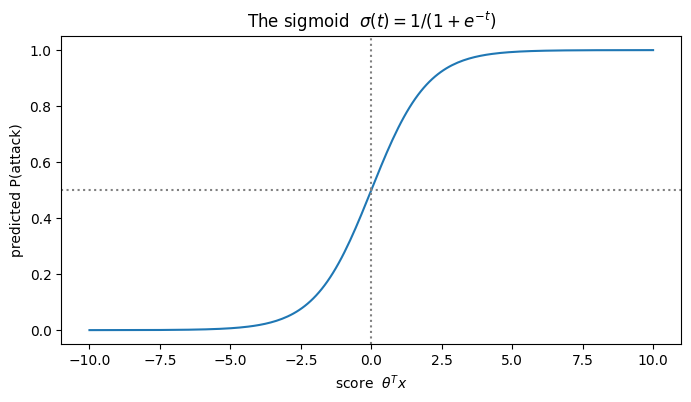

In [ ]:
t = np.linspace(-10, 10, 200)
plt.plot(t, 1 / (1 + np.exp(-t)))
plt.axhline(0.5, color='grey', ls=':'); plt.axvline(0, color='grey', ls=':')
plt.title(r'The sigmoid  $\sigma(t)=1/(1+e^{-t})$'); plt.xlabel('score  $\\theta^T x$')
plt.ylabel('predicted P(attack)'); plt.show()

## B2. Two knobs that decide everything: scaling and the regularization `C`

`scikit-learn`'s `LogisticRegression` is **regularized by default**, controlled by a parameter **`C`**.
Careful: `C` is the *inverse* of the `α` we saw for Ridge — **small `C` = strong regularization**, large
`C` = weak. (So `C → 0` is like `α → ∞`: it forces all coefficients toward zero.)

The lecture's notebook shows a striking failure: with tiny `C` **and unscaled features**, the classifier
becomes a useless coin-flip. Let's reproduce it on our data, then fix it.

In [ ]:
# stratify keeps the same attack/normal ratio in train and test
dtr, dte = train_test_split(df, test_size=0.3, random_state=19, stratify=df['is_attack'])
ytr = dtr['is_attack'].values
yte = dte['is_attack'].values

# (a) BAD: huge regularization, no scaling -> coefficients crushed to ~0 -> always predicts majority class
bad = LogisticRegression(C=1e-9, max_iter=1000).fit(dtr[FEATURES], ytr)
acc_bad = accuracy_score(yte, bad.predict(dte[FEATURES]))

# (b) GOOD: scale first, sensible C=1
good = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=1000)).fit(dtr[FEATURES], ytr)
acc_good = accuracy_score(yte, good.predict(dte[FEATURES]))

print(f'(a) C=1e-9, unscaled : accuracy = {acc_bad:.4f}   <- basically the share of normal traffic (a coin flip)')
print(f'(b) scaled, C=1      : accuracy = {acc_good:.4f}   <- a real intrusion detector')

(a) C=1e-9, unscaled : accuracy = 0.5339   <- basically the share of normal traffic (a coin flip)
(b) scaled, C=1      : accuracy = 0.9443   <- a real intrusion detector


The bad model scores ≈ **0.53** — exactly the proportion of `normal` traffic, because crushing the
coefficients makes it predict "normal" for everything (slide 11's `α → ∞` extreme). Scale the features and
use a reasonable `C`, and the **same algorithm** jumps to ≈ **0.94**. Two lines of preprocessing, +40 points
of accuracy. Now sweep `C` to see the regularization trade-off directly.

In [ ]:
print(f'{"C":>10}   {"test accuracy":>13}')
for C in [1e-4, 1e-2, 0.1, 1, 10, 100]:
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000)).fit(dtr[FEATURES], ytr)
    print(f'{C:>10}   {accuracy_score(yte, clf.predict(dte[FEATURES])):>13.4f}')

         C   test accuracy
    0.0001          0.9110
      0.01          0.9393
       0.1          0.9440
         1          0.9443
        10          0.9444
       100          0.9444


Strong regularization (`C = 10⁻⁴`) underfits a little (≈ 0.91); from `C = 1` onward the accuracy
plateaus (≈ 0.944). Our model is **not** overfitting — more freedom doesn't hurt — so any `C ≳ 1` is fine.
We will let cross-validation pick the exact value in B7.

## B3. The decision boundary

A logistic classifier splits the feature space into a "predict 1" region and a "predict 0" region; the
border between them is the **decision boundary**. The lecture proves it is always a **straight line / flat
plane** (a *hyperplane*, slide 29), because the model predicts 1 exactly when `θᵀx ≥ 0`.

Let's draw it for two scaled features so we can see it in 2-D, the way the course notebook does with the
video data.

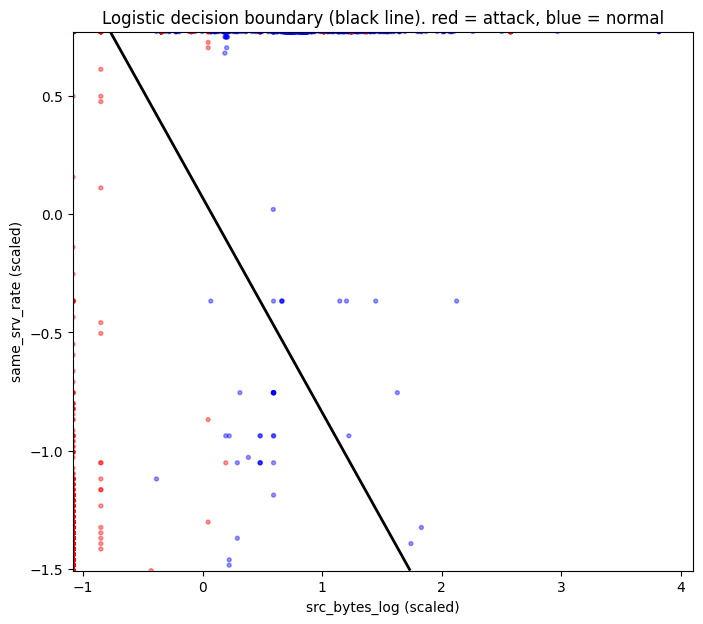

2-feature test accuracy: 0.8767


In [ ]:
two = ['src_bytes_log', 'same_srv_rate']
scaler2 = StandardScaler().fit(dtr[two])
Xtr2 = scaler2.transform(dtr[two]); Xte2 = scaler2.transform(dte[two])
clf2 = LogisticRegression(C=1, max_iter=2000).fit(Xtr2, ytr)

# scatter a sample of the (scaled) test points, coloured by true class
fig, ax = plt.subplots(figsize=(8, 7))
idx = np.random.RandomState(0).choice(len(Xte2), 1500, replace=False)
ax.scatter(Xte2[idx, 0], Xte2[idx, 1], c=yte[idx], cmap='bwr', s=8, alpha=0.4)

# build a grid, ask the model for P(attack) at every grid point, draw the 0.5 contour
xx, yy = np.meshgrid(np.linspace(Xte2[:,0].min(), Xte2[:,0].max(), 300),
                     np.linspace(Xte2[:,1].min(), Xte2[:,1].max(), 300))
proba = clf2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=2)
ax.set(xlabel='src_bytes_log (scaled)', ylabel='same_srv_rate (scaled)',
       title='Logistic decision boundary (black line). red = attack, blue = normal')
plt.show()
print('2-feature test accuracy:', round(accuracy_score(yte, clf2.predict(Xte2)), 4))

The black line is the boundary: everything on one side is predicted *attack*, the other *normal*. It is
**straight**, as the theorem promised. With just these two features we already reach ≈ 0.88 accuracy; the
points that fall on the wrong side are the errors a *linear* boundary cannot avoid (a curved boundary —
e.g. polynomial features — could capture some of them, at the risk of overfitting).

## B4. Measuring a classifier properly: the confusion matrix

Accuracy ("what fraction did I get right?") is a single number that can hide a lot. The **confusion matrix**
shows *which* mistakes the model makes: rows = true class, columns = predicted class. The diagonal is
correct; everything off-diagonal is an error. From it we read three key metrics (slide 38):

* **Precision** of a class = of everything I *labelled* this class, what fraction really was? (few false alarms)
* **Recall** of a class = of everything that *truly* is this class, what fraction did I catch? (few misses)
* **F1** = the harmonic mean of the two — a single score that is only high when *both* are high.

For intrusion detection, **recall on the attack classes** is what keeps you safe: a missed attack is a
breach.

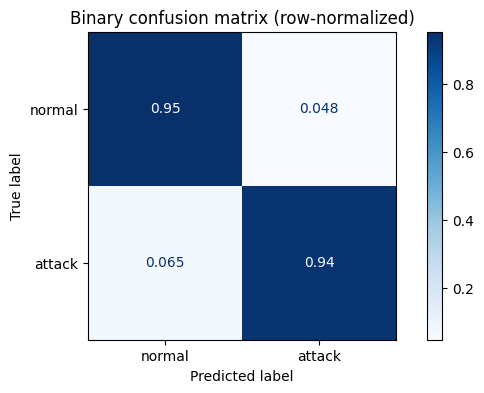

              precision    recall  f1-score   support

      normal       0.94      0.95      0.95      4035
      attack       0.94      0.94      0.94      3523

    accuracy                           0.94      7558
   macro avg       0.94      0.94      0.94      7558
weighted avg       0.94      0.94      0.94      7558



In [ ]:
good = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=1000)).fit(dtr[FEATURES], ytr)
yp = good.predict(dte[FEATURES])

ConfusionMatrixDisplay.from_predictions(yte, yp, display_labels=['normal', 'attack'],
                                        normalize='true', cmap='Blues')
plt.title('Binary confusion matrix (row-normalized)'); plt.show()

print(classification_report(yte, yp, target_names=['normal', 'attack']))

On the *binary* task the model is well-balanced: both classes get ≈ 0.94 precision and recall, because
attack and normal are roughly equal in size. That comfort disappears the moment we ask a harder question —
*which kind* of attack — because the categories are wildly imbalanced. That is the next section.

## B5. Multinomial Logistic Regression — naming the attack family

Real intrusion detection wants more than "attack/normal": it wants **DoS vs Probe vs R2L vs U2R vs normal**.
Logistic regression extends to *K* classes via the **softmax** (slide 30): it computes a score for each
class and turns the scores into probabilities that sum to 1; the predicted class is the highest.
`scikit-learn` does this automatically when `y` has more than two values.

Overall accuracy: 0.9348 

              precision    recall  f1-score   support

         DoS       0.96      0.95      0.95      2770
       Probe       0.84      0.80      0.82       687
         R2L       0.80      0.38      0.52        63
         U2R       0.00      0.00      0.00         3
      normal       0.94      0.96      0.95      4035

    accuracy                           0.93      7558
   macro avg       0.71      0.62      0.65      7558
weighted avg       0.93      0.93      0.93      7558



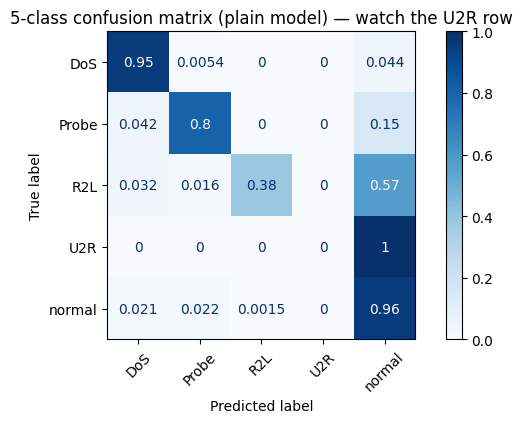

In [ ]:
dtr, dte = train_test_split(df, test_size=0.3, random_state=19, stratify=df['category'])
ytr_c = dtr['category'].values
yte_c = dte['category'].values

multi = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=3000)).fit(dtr[FEATURES], ytr_c)
yp_c = multi.predict(dte[FEATURES])

print('Overall accuracy:', round(accuracy_score(yte_c, yp_c), 4), '\n')
print(classification_report(yte_c, yp_c, zero_division=0))
ConfusionMatrixDisplay.from_predictions(yte_c, yp_c, normalize='true', cmap='Blues',
                                        xticks_rotation=45)
plt.title('5-class confusion matrix (plain model) — watch the U2R row'); plt.show()

**93% accuracy — and yet the model is partly broken.** Look at the report and the confusion matrix:

* `normal` and `DoS` are nailed (F1 ≈ 0.95) — they have thousands of samples.
* `Probe` is decent (F1 ≈ 0.82).
* `R2L` is weak: recall ≈ 0.38 — it misses most remote-to-local attacks.
* `U2R` is a **total failure**: precision = recall = **0.00**. The rarest, most dangerous class (root
  exploits) is *never once* correctly predicted.

This is the lecture's central warning (slide 37): **accuracy is misleading under class imbalance.** A model
can score 93% by being excellent on the big classes and ignoring the small ones — and for a security tool,
ignoring U2R is the worst possible failure.

## B6. Class imbalance — making the rare attacks visible

The fix is to stop letting the big classes dominate training. The lecture lists three ideas (slide 37); we
try the two most useful.

**Idea 1 — re-weight the loss (`class_weight='balanced'`).** Tell the model that an error on a rare class
costs more, in inverse proportion to the class size. One line, no new data.

**Idea 2 — SMOTE** (*Synthetic Minority Over-sampling*, slide 37). Instead of just copying minority samples,
SMOTE creates **new synthetic** ones along the lines between a minority sample and its nearest minority
neighbours, until every class is the same size. The course uses `imblearn`'s `SMOTE`; to keep this notebook
install-free we implement the same idea in ~15 lines below.

⚠️ Both balancing tricks are applied to the **training set only** — never the test set, which must stay a
faithful picture of reality.

In [ ]:
# --- Idea 1: class_weight='balanced' ---
bal = make_pipeline(StandardScaler(),
                    LogisticRegression(C=1, max_iter=3000, class_weight='balanced')).fit(dtr[FEATURES], ytr_c)
yp_bal = bal.predict(dte[FEATURES])
print('=== class_weight="balanced" ===')
print('accuracy:', round(accuracy_score(yte_c, yp_bal), 4),
      '| macro-F1:', round(f1_score(yte_c, yp_bal, average='macro', zero_division=0), 4))
print(classification_report(yte_c, yp_bal, zero_division=0))

=== class_weight="balanced" ===
accuracy: 0.8396 | macro-F1: 0.5469
              precision    recall  f1-score   support

         DoS       0.96      0.94      0.95      2770
       Probe       0.61      0.93      0.74       687
         R2L       0.09      0.78      0.17        63
         U2R       0.02      0.67      0.03         3
      normal       0.97      0.75      0.85      4035

    accuracy                           0.84      7558
   macro avg       0.53      0.81      0.55      7558
weighted avg       0.93      0.84      0.87      7558



class sizes after SMOTE: {'normal': np.int64(9414), 'DoS': np.int64(9414), 'Probe': np.int64(9414), 'R2L': np.int64(9414), 'U2R': np.int64(9414)}

=== SMOTE ===
accuracy: 0.8488 | macro-F1: 0.555
              precision    recall  f1-score   support

         DoS       0.96      0.95      0.95      2770
       Probe       0.62      0.94      0.75       687
         R2L       0.10      0.79      0.18        63
         U2R       0.02      0.67      0.04         3
      normal       0.97      0.77      0.86      4035

    accuracy                           0.85      7558
   macro avg       0.53      0.82      0.55      7558
weighted avg       0.93      0.85      0.88      7558



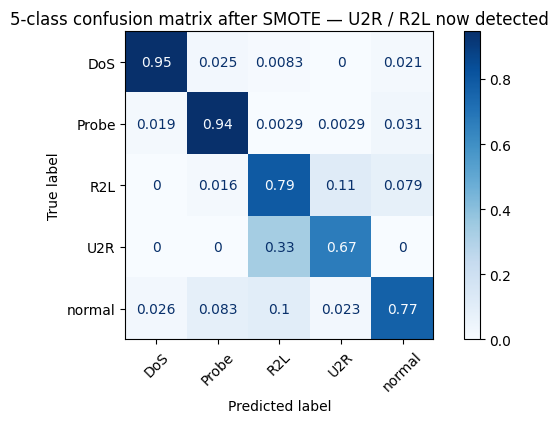

In [ ]:
# --- Idea 2: a minimal SMOTE (same idea as imblearn.over_sampling.SMOTE) ---
from sklearn.neighbors import NearestNeighbors

def smote_balance(X, y, k=5, seed=0):
    # Oversample every minority class up to the majority size by interpolating
    # between a sample and one of its k nearest same-class neighbours.
    rng = np.random.RandomState(seed)
    X = np.asarray(X, float); y = np.asarray(y)
    n_max = pd.Series(y).value_counts().max()
    X_parts, y_parts = [X], [y]
    for c in np.unique(y):
        Xc = X[y == c]; n = len(Xc); need = n_max - n
        if need <= 0:
            continue
        if n == 1:                                   # can't interpolate -> duplicate
            X_parts.append(np.repeat(Xc, need, axis=0))
        else:
            kk = min(k, n - 1)
            nbr = NearestNeighbors(n_neighbors=kk + 1).fit(Xc).kneighbors(Xc, return_distance=False)
            base = rng.randint(0, n, need)
            new = [Xc[b] + rng.rand() * (Xc[nbr[b, 1 + rng.randint(kk)]] - Xc[b]) for b in base]
            X_parts.append(np.array(new))
        y_parts.append(np.array([c] * need))
    return np.vstack(X_parts), np.concatenate(y_parts)

# scale on train, balance the (scaled) training set, train a plain logistic regression
scaler = StandardScaler().fit(dtr[FEATURES])
Xtr_s, Xte_s = scaler.transform(dtr[FEATURES]), scaler.transform(dte[FEATURES])
Xtr_bal, ytr_bal = smote_balance(Xtr_s, ytr_c)
print('class sizes after SMOTE:', dict(pd.Series(ytr_bal).value_counts()))

sm = LogisticRegression(C=1, max_iter=3000).fit(Xtr_bal, ytr_bal)
yp_sm = sm.predict(Xte_s)
print('\n=== SMOTE ===')
print('accuracy:', round(accuracy_score(yte_c, yp_sm), 4),
      '| macro-F1:', round(f1_score(yte_c, yp_sm, average='macro', zero_division=0), 4))
print(classification_report(yte_c, yp_sm, zero_division=0))
ConfusionMatrixDisplay.from_predictions(yte_c, yp_sm, normalize='true', cmap='Blues',
                                        xticks_rotation=45)
plt.title('5-class confusion matrix after SMOTE — U2R / R2L now detected'); plt.show()

**The trade-off, stated honestly.** Balancing (either way) does exactly what the lecture predicts:

| | plain | balanced / SMOTE |
|---|---|---|
| overall accuracy | ≈ 0.93 | ≈ 0.85 |
| **U2R recall** | **0.00** | **≈ 0.67** |
| **R2L recall** | ≈ 0.38 | ≈ 0.78 |

Accuracy *drops* by ~8 points, yet the model now actually **catches** the rare U2R and R2L attacks it used
to ignore entirely. The cost is more false alarms on those tiny classes (their precision is low), which is
why macro-F1 barely moves. For a security tool this is usually the **right** trade: missing a root-level
U2R exploit (a real breach) is far worse than a few false alarms an analyst can dismiss. The "better" model
is the one whose mistakes you can live with — not the one with the biggest accuracy number.

*(U2R has only ~8 training and ~3 test samples, so its individual numbers are noisy — treat them as
directional, not precise.)*

## B7. Hyper-parameter tuning, done right: `GridSearchCV`

We have met several hyper-parameters (`C`, the degree, `α`). The disciplined way to choose them (slides 5,
19) is: try each value, score it by **cross-validation on the training set only**, keep the best, and report
the final score **once** on the untouched test set. `GridSearchCV` automates the whole loop.

Because the classes are imbalanced we score by **`f1_macro`** (which averages F1 over classes, giving the
rare ones equal say) rather than accuracy — otherwise the search would just chase the big classes.

In [ ]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight='balanced'))
param_grid = {'logisticregression__C': [1e-4, 1e-2, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, param_grid, cv=KFold(5, shuffle=True, random_state=6), scoring='f1_macro')
grid.fit(dtr[FEATURES], ytr_c)

print('best C        :', grid.best_params_['logisticregression__C'])
print('best CV f1    :', round(grid.best_score_, 4))
best = grid.best_estimator_
yp_best = best.predict(dte[FEATURES])
print('test accuracy :', round(accuracy_score(yte_c, yp_best), 4))
print('test macro-F1 :', round(f1_score(yte_c, yp_best, average='macro', zero_division=0), 4))

best C        : 100
best CV f1    : 0.5589
test accuracy : 0.8444
test macro-F1 : 0.552


Cross-validation chose `C` for us automatically, and the held-out test score confirms the choice — we
selected the model **without ever peeking at the test set**, exactly the honest workflow from slide 5.

## Summary — what we did and what we found

**Method (mirrors the lecture, both halves):**
polynomial features & degree tuning → bias–variance curve → Ridge regularization (`α`) → scaling &
data-leakage-safe pipelines → RFE feature selection → **Logistic Regression** → decision boundary →
confusion matrix / precision-recall-F1 → **Multinomial** logistic regression → **class imbalance**
(class-weights & SMOTE) → `GridSearchCV` hyper-parameter tuning.

**Findings on NSL-KDD:**
1. **Bias–variance is real and visible.** Polynomial degree on `src_bytes_log` gives a textbook U-shaped
   test-error curve: best at **degree 3** (test RMSE ≈ 0.28); by degree 7 the model overfits badly
   (test RMSE ≈ 0.64 while *training* error keeps falling).
2. **Regularization rescues overfitting.** Ridge with `α ≈ 5000` pulls that degree-7 model's test RMSE from
   0.64 back to ≈ 0.33; too much (`α = 20000`) over-regularizes. `α` has its own U-shaped curve.
3. **Scaling + sensible `C` make or break logistic regression.** Tiny `C` on unscaled features collapses to
   a 53% coin-flip; scaling + `C = 1` gives a **94%** intrusion detector — same algorithm, two lines of prep.
4. **RFE re-ranks the features.** `dst_bytes_log` is the single most useful predictor in the presence of the
   others (not `same_srv_rate`, which led by raw correlation), and the **top 8 features match all 10's
   accuracy** — two are redundant.
5. **Accuracy lies under imbalance.** The 5-class model scores 93% yet **never detects a single U2R attack**.
   Balancing (class-weights or SMOTE) trades ~8 points of accuracy to recover U2R recall (0 → ~0.67) and R2L
   recall (0.38 → ~0.78) — the right call for a security tool, where a missed root exploit beats a false alarm.

**Connections to Day 2:** the *Linear Probability Model* we built on Day 2 is now replaced by its proper
counterpart, **Logistic Regression**, which can never predict an impossible probability; the log-transform,
train/test discipline and cross-validation all carry straight over.

**Caveat:** we only ever trained on the `KDDTrain+_20Percent` subset. NSL-KDD ships a separate `KDDTest+`
set whose attack mix differs on purpose — a fair next step would be to evaluate there, where these numbers
typically drop (the honest test of generalization).
